In [2]:
# Импортируем необходимые библиотеки
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

### Задание 1. Загрузка и первичный осмотр

In [3]:
# Читаем файл
path = 'D:\\work\\DQ\\lesson_4\\computer_games.csv'
df = pd.read_csv(path)

In [12]:
#Выводим общую информацию о содержимом
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       7590 non-null   float64
 10  Rating           9949 non-null   object 
dtypes: float64(7), object(4)
memory usage: 1.4+ MB


In [5]:
#Предпросмотр первых строк
df.head(10)

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
6,New Super Mario Bros.,DS,2006.0,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E
7,Wii Play,Wii,2006.0,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E
8,New Super Mario Bros. Wii,Wii,2009.0,Platform,14.44,6.94,4.70,2.24,87.0,8.4,E
9,Duck Hunt,NES,1984.0,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN


### Задание 2. Очистка и подготовка данных

In [5]:
# Приводим тип данных оценок к вещественному
print(df['User_Score'].unique())

df.loc[df['User_Score']=='tbd', 'User_Score'] = np.nan
df['User_Score'] = df['User_Score'].astype('float')

print(df['User_Score'].unique())

['8' nan '8.3' '8.5' '6.6' '8.4' '8.6' '7.7' '6.3' '7.4' '8.2' '9' '7.9'
 '8.1' '8.7' '7.1' '3.4' '5.3' '4.8' '3.2' '8.9' '6.4' '7.8' '7.5' '2.6'
 '7.2' '9.2' '7' '7.3' '4.3' '7.6' '5.7' '5' '9.1' '6.5' 'tbd' '8.8' '6.9'
 '9.4' '6.8' '6.1' '6.7' '5.4' '4' '4.9' '4.5' '9.3' '6.2' '4.2' '6' '3.7'
 '4.1' '5.8' '5.6' '5.5' '4.4' '4.6' '5.9' '3.9' '3.1' '2.9' '5.2' '3.3'
 '4.7' '5.1' '3.5' '2.5' '1.9' '3' '2.7' '2.2' '2' '9.5' '2.1' '3.6' '2.8'
 '1.8' '3.8' '0' '1.6' '9.6' '2.4' '1.7' '1.1' '0.3' '1.5' '0.7' '1.2'
 '2.3' '0.5' '1.3' '0.2' '0.6' '1.4' '0.9' '1' '9.7']
[8.  nan 8.3 8.5 6.6 8.4 8.6 7.7 6.3 7.4 8.2 9.  7.9 8.1 8.7 7.1 3.4 5.3
 4.8 3.2 8.9 6.4 7.8 7.5 2.6 7.2 9.2 7.  7.3 4.3 7.6 5.7 5.  9.1 6.5 8.8
 6.9 9.4 6.8 6.1 6.7 5.4 4.  4.9 4.5 9.3 6.2 4.2 6.  3.7 4.1 5.8 5.6 5.5
 4.4 4.6 5.9 3.9 3.1 2.9 5.2 3.3 4.7 5.1 3.5 2.5 1.9 3.  2.7 2.2 2.  9.5
 2.1 3.6 2.8 1.8 3.8 0.  1.6 9.6 2.4 1.7 1.1 0.3 1.5 0.7 1.2 2.3 0.5 1.3
 0.2 0.6 1.4 0.9 1.  9.7]


In [14]:
# Вывод пропусков с годом выпуска игры
display(df[df['Year_of_Release'].isna()].head(5))

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating,Decade_YOR,Total_Sales
183,Madden NFL 2004,PS2,NaN,Sports,4.26,0.26,0.01,0.71,94.0,8.5,E,Unknown,5.24
377,FIFA Soccer 2004,PS2,NaN,Sports,0.59,2.36,0.04,0.51,84.0,6.4,E,Unknown,3.50
456,LEGO Batman: The Videogame,Wii,NaN,Action,1.80,0.97,0.00,0.29,74.0,7.9,E10+,Unknown,3.06
475,wwe Smackdown vs. Raw 2006,PS2,NaN,Fighting,1.57,1.02,0.00,0.41,NaN,NaN,NaN,Unknown,3.00
609,Space Invaders,2600,NaN,Shooter,2.36,0.14,0.00,0.03,NaN,NaN,NaN,Unknown,2.53


In [6]:
# Получаем диапазон годов релиза для каждой платформы, а также медианное значение
df_yor_med = pd.pivot_table(
    df,
    values=['Year_of_Release'],
    index=['Platform'],
    aggfunc={'Year_of_Release': {'min', 'median', 'max'}},
    fill_value=0
)

# Заполняем пропуски в годе релиза
def get_yor(row):

    yor = row['Year_of_Release']
    if np.isnan(yor):
        numbers_yor = re.findall(r'\d{4}', row['Name'])
        for number in numbers_yor:
            if (int(number) >= df_yor_med.loc[row['Platform']].get('Year_of_Release').get('min')) & (int(number) <= df_yor_med.loc[row['Platform']].get('Year_of_Release').get('max')):
                yor = int(number)
            else:
                yor = int(df_yor_med.loc[row['Platform']].get('Year_of_Release').get('median'))

        if np.isnan(yor):
            yor = int(df_yor_med.loc[row['Platform']].get('Year_of_Release').get('median'))
    else:
        yor = row['Year_of_Release']

    return yor
        
df['Year_of_Release'] = df.apply(get_yor, axis=1)

In [16]:
#Проверка заполнения пропусков
df.loc[[183,377,456]]

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating,Decade_YOR,Total_Sales
183,Madden NFL 2004,PS2,2004.0,Sports,4.26,0.26,0.01,0.71,94.0,8.5,E,Unknown,5.24
377,FIFA Soccer 2004,PS2,2004.0,Sports,0.59,2.36,0.04,0.51,84.0,6.4,E,Unknown,3.50
456,LEGO Batman: The Videogame,Wii,2009.0,Action,1.80,0.97,0.00,0.29,74.0,7.9,E10+,Unknown,3.06


In [29]:
#Анализ значений в колонке Rating
print(pd.pivot_table(
    df,
    values=['Rating'],
    index=['Platform'],
    aggfunc={'Rating': 'count'},
    fill_value=0
))
print()
print(df.groupby('Rating')['Name'].count())

          Rating
Platform        
2600           0
3DO            0
3DS          228
DC            14
DS          1273
GB             0
GBA          522
GC           469
GEN            0
GG             0
N64            0
NES            0
NG             0
PC           774
PCFX           0
PS           208
PS2         1481
PS3          952
PS4          255
PSP          544
PSV          151
SAT            0
SCD            0
SNES           0
TG16           0
WS             0
Wii         1002
WiiU         105
X360        1052
XB           733
XOne         186

Rating
AO         1
E       3990
E10+    1420
EC         8
K-A        3
M       1563
RP         3
T       2961
Name: Name, dtype: int64


### Задание 3. Общие продажи

In [7]:
#Добавить столбец с общими продажами и вывести топ-10 игр по общим продажам
df['Total_Sales'] = df['NA_sales'] + df['EU_sales'] + df['JP_sales'] + df['Other_sales']
df.sort_values(by='Total_Sales', ascending=False).head(10)

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating,Total_Sales
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN,40.24
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN,31.38
5,Tetris,GB,1989.0,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN,30.26
6,New Super Mario Bros.,DS,2006.0,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E,29.80
7,Wii Play,Wii,2006.0,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E,28.91
8,New Super Mario Bros. Wii,Wii,2009.0,Platform,14.44,6.94,4.70,2.24,87.0,8.4,E,28.32
9,Duck Hunt,NES,1984.0,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN,28.31


### Задание 4. Визуализация распределения продаж

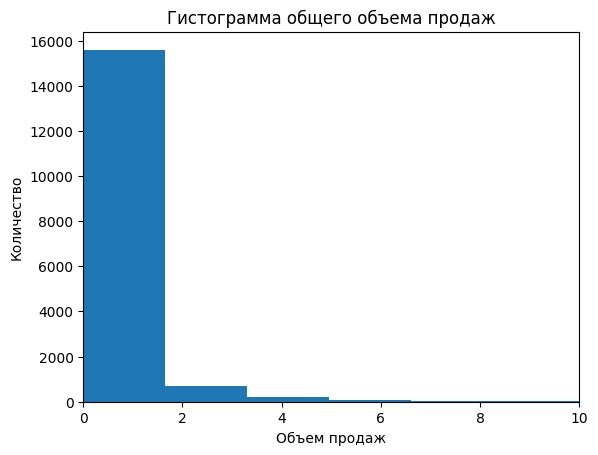

In [33]:
#Построить гистограммы распределения общего объема продаж
plt.hist(df['Total_Sales'], bins=50)
#plt.xscale('log')
plt.xlim(0,10)
plt.title('Гистограмма общего объема продаж')
plt.xlabel('Объем продаж')
plt.ylabel('Количество')
plt.show()

### Задание 5. Анализ по жанрам

,Genre,Games_Count,Average_Sales,Median_Sales,Sum_Sales,Average_Critic_Score,Average_User_Score
4,Platform,888,0.932173,0.27,827.77,68.058350,7.301402
8,Shooter,1323,0.795503,0.24,1052.45,70.181144,7.041883
7,Role-Playing,1498,0.623872,0.18,934.56,72.652646,7.619515
6,Racing,1249,0.583403,0.19,728.67,67.963612,7.036193
10,Sports,2348,0.566980,0.22,1331.27,71.968174,6.961197
2,Fighting,849,0.527126,0.21,447.53,69.217604,7.302506
0,Action,3369,0.517711,0.19,1744.17,66.629101,7.054044
3,Misc,1750,0.458577,0.16,802.51,66.619503,6.819362
9,Simulation,873,0.446701,0.15,389.97,68.619318,7.134593
5,Puzzle,580,0.418224,0.11,242.57,67.424107,7.175000


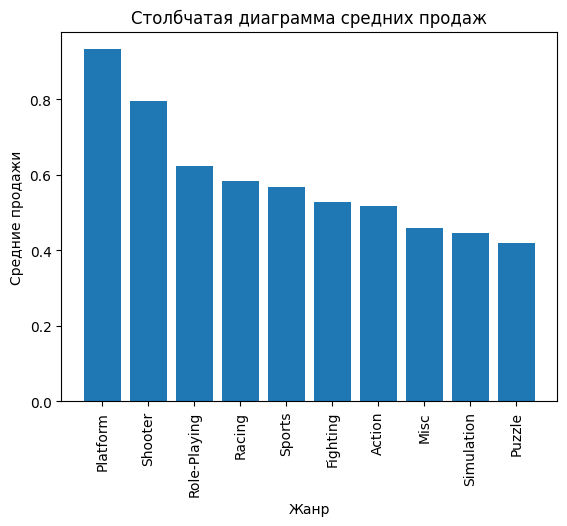

In [38]:
#Анализ по жанрам
multi_agg = df.groupby(['Genre']).agg(
    Games_Count=('Name', 'count'),
    Average_Sales=('Total_Sales', 'mean'),
    Median_Sales=('Total_Sales', 'median'),
    Sum_Sales=('Total_Sales', 'sum'),
    Average_Critic_Score=('Critic_Score', 'mean'),
    Average_User_Score=('User_Score', 'mean')
).reset_index()

result = multi_agg.sort_values(by='Average_Sales', ascending=False)
display(result)

plt.bar(result.head(10).Genre, result.head(10).Average_Sales)
plt.title('Столбчатая диаграмма средних продаж')
plt.xlabel('Жанр', fontsize = 10) 
plt.xticks(rotation=90)
plt.ylabel('Средние продажи', fontsize = 10) 
plt.show()

### Задание 6. Динамика продаж по годам

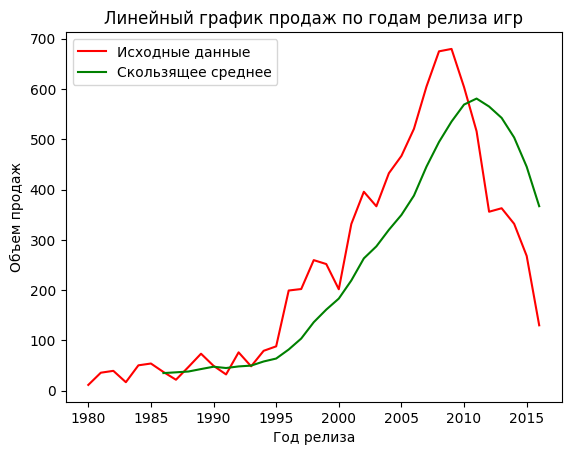

In [47]:
#Динамика продаж по годам
sales_by_yor = df.groupby('Year_of_Release')['Total_Sales'].sum()

x = sales_by_yor.index
y = sales_by_yor.values
rolling_avg = sales_by_yor.rolling(window=7).mean()

plt.plot(x, y, color ='r', label='Исходные данные') 
plt.plot(x, rolling_avg, color ='g', label='Скользящее среднее')

plt.title('Линейный график продаж по годам релиза игр')
plt.xlabel('Год релиза', fontsize = 10)
plt.ylabel('Объем продаж', fontsize = 10)
plt.legend()
plt.show()

### Задание 7. Региональные предпочтения

In [50]:
#Региональные предпочтения
multi_agg = df.groupby(['Genre']).agg(
    NA_Sales=('NA_sales', 'sum'),
    EU_Sales=('EU_sales', 'sum'),
    JP_sales=('JP_sales', 'sum')
).reset_index()

display(multi_agg[['Genre', 'NA_Sales']].sort_values(by='NA_Sales', ascending=False).head(5))
display(multi_agg[['Genre', 'EU_Sales']].sort_values(by='EU_Sales', ascending=False).head(5))
display(multi_agg[['Genre', 'JP_sales']].sort_values(by='JP_sales', ascending=False).head(5))

,Genre,NA_Sales
0,Action,879.01
10,Sports,684.43
8,Shooter,592.24
4,Platform,445.50
3,Misc,407.27


,Genre,EU_Sales
0,Action,519.13
10,Sports,376.79
8,Shooter,317.34
6,Racing,236.51
3,Misc,212.74


,Genre,JP_sales
7,Role-Playing,355.41
0,Action,161.43
10,Sports,135.54
4,Platform,130.83
3,Misc,108.11


### Задание 8. Связь оценок и продаж

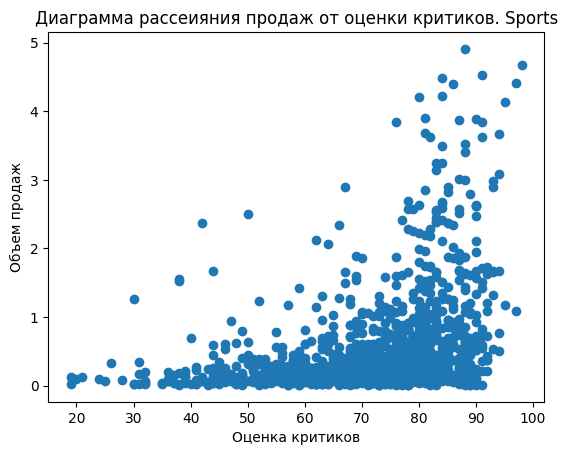

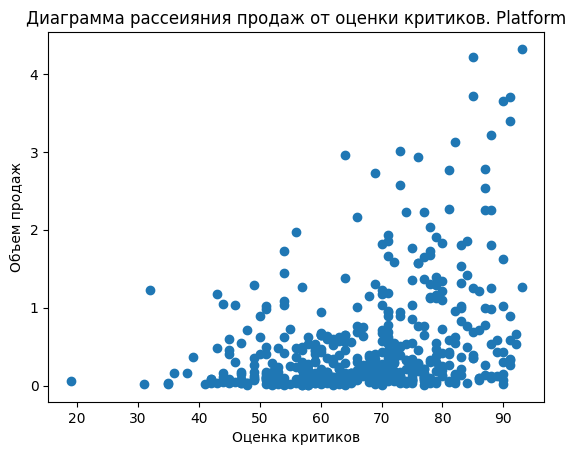

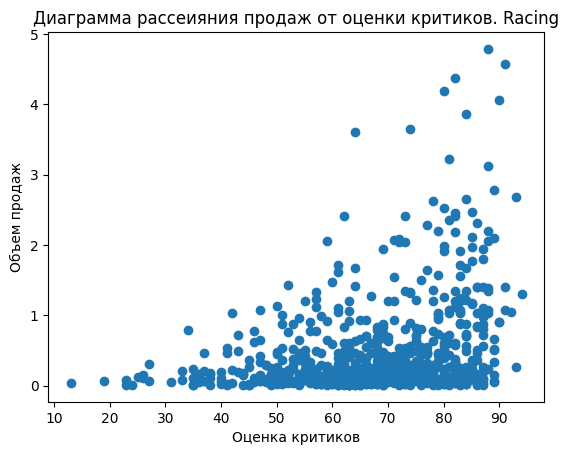

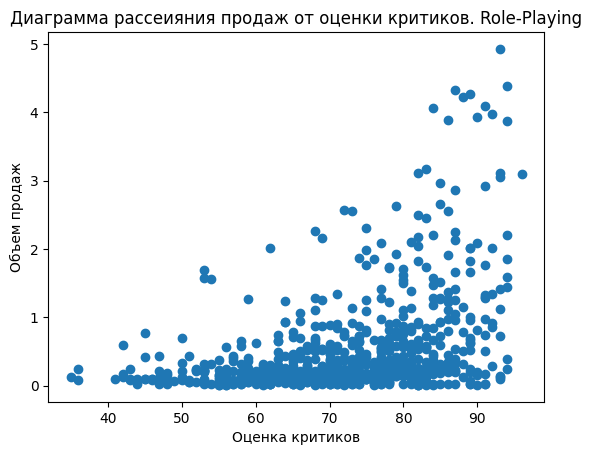

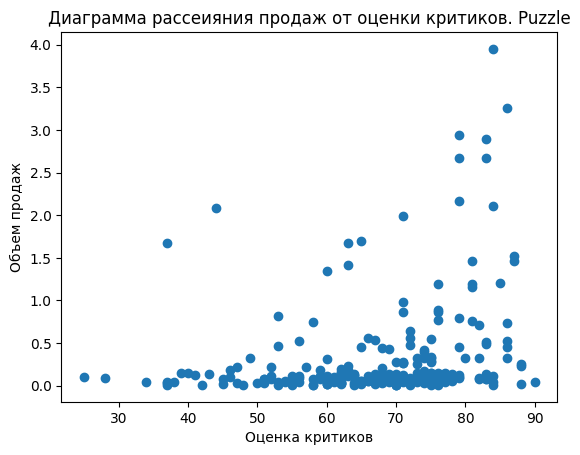

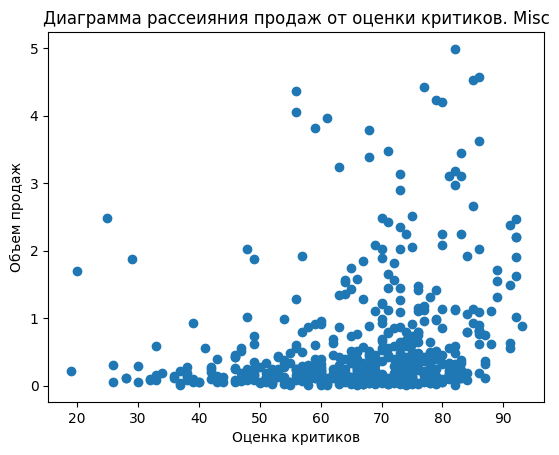

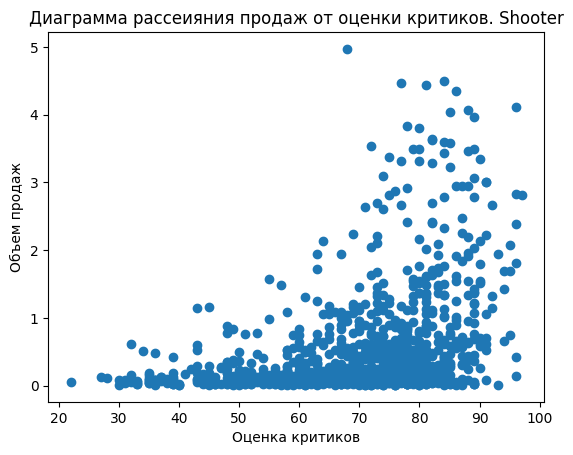

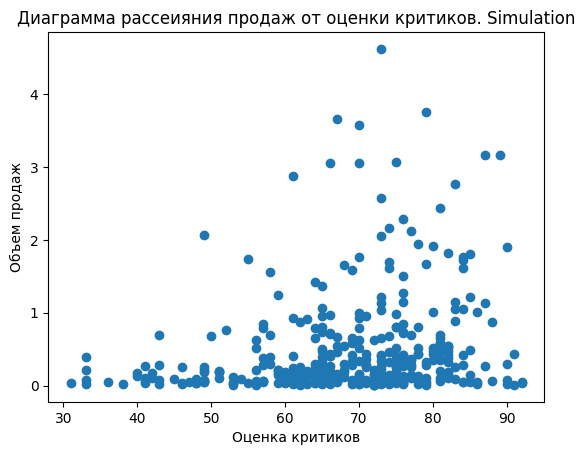

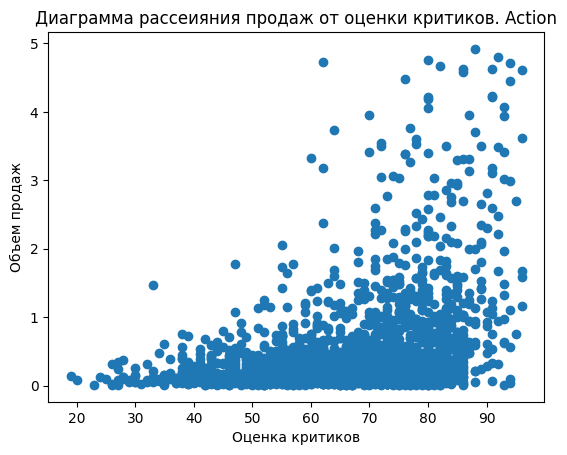

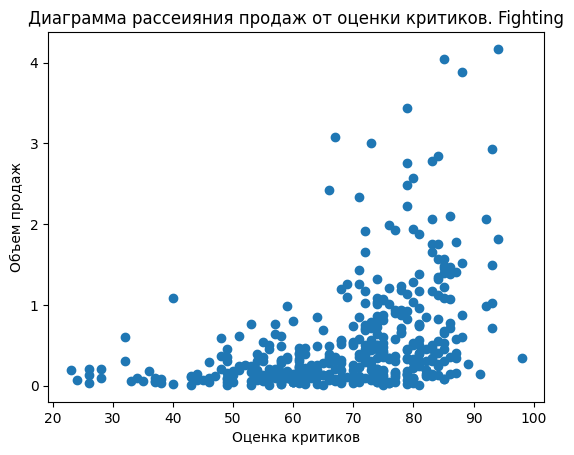

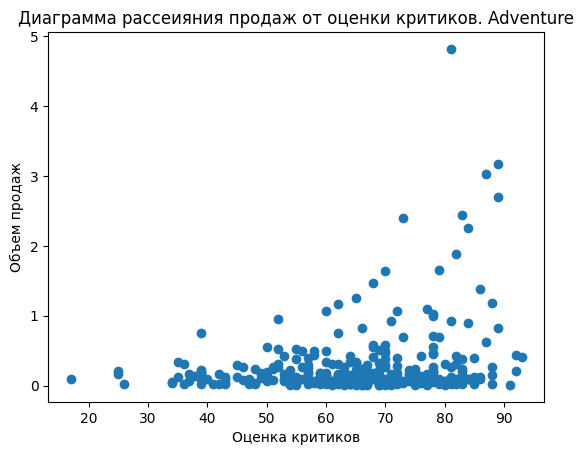

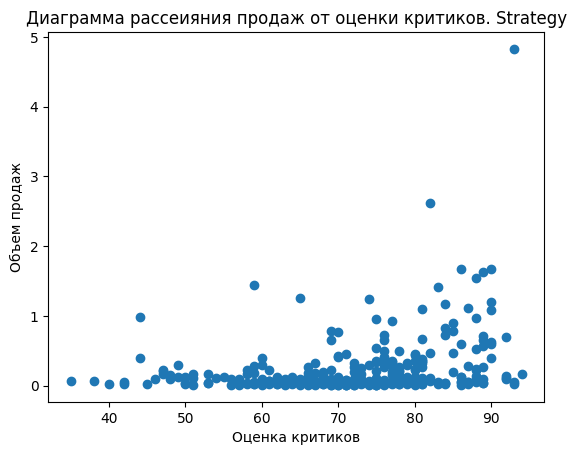

,Critic_Score,User_Score,Total_Sales
Critic_Score,1.000000,0.580878,0.245507
User_Score,0.580878,1.000000,0.088179
Total_Sales,0.245507,0.088179,1.000000


In [60]:
#Построить диаграмму рассеяния
genres = list(df[~df['Genre'].isna()]['Genre'].unique())

for genre in genres:
    games_query = f'(Total_Sales < 5) & (Genre == \"{genre}\")'
    plt.scatter(df.query(games_query)['Critic_Score'], df.query(games_query)['Total_Sales'])
    plt.title(f'Диаграмма рассеияния продаж от оценки критиков. {genre}')
    plt.xlabel('Оценка критиков', fontsize = 10)
    plt.ylabel('Объем продаж', fontsize = 10)
    plt.show()
    print()

#Вычислить коэффициент корреляции
display(df[['Critic_Score', 'User_Score', 'Total_Sales']].corr(method='pearson'))

### Задание 9. Успешность игры по рейтингу ESRB

,Rating,Games_Count,Average_Sales,Median_Critic_Score
0,AO,1,1.960000,93.0
4,K-A,3,1.440000,92.0
5,M,1563,0.942924,74.0
1,E,3990,0.610406,70.0
7,T,2961,0.504340,71.0
2,E10+,1420,0.461690,68.0
3,EC,8,0.218750,NaN
6,RP,3,0.030000,63.0


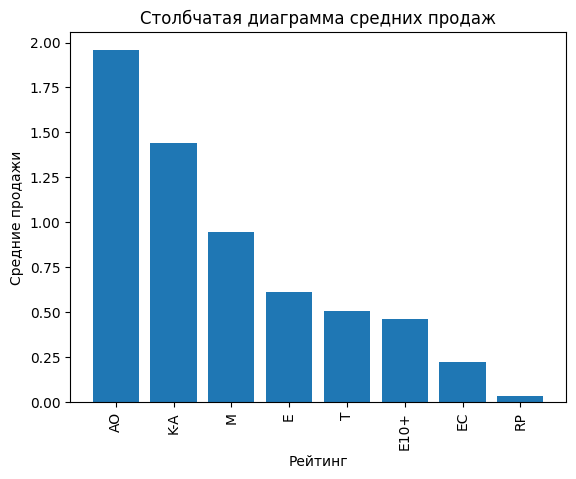

In [63]:
#Анализ рейтинга игры
multi_agg = df.groupby(['Rating']).agg(
    Games_Count=('Name', 'count'),
    Average_Sales=('Total_Sales', 'mean'),
    Median_Critic_Score=('Critic_Score', 'median')
).reset_index()

result = multi_agg.sort_values(by='Average_Sales', ascending=False)
display(result)

plt.bar(result.Rating, result.Average_Sales)
plt.title('Столбчатая диаграмма средних продаж')
plt.xlabel('Рейтинг', fontsize = 10) 
plt.xticks(rotation=90)
plt.ylabel('Средние продажи', fontsize = 10) 
plt.show()

### Задание 10. Игры-рекордсмены в отдельных регионах

In [69]:
#Игры-рекордсмены в регионах
print('Игры-рекордсмены в Северной Америке')
display(df[(df['NA_sales'] > 3*df['JP_sales']) & (df['NA_sales'] > 3*df['EU_sales'])].head(5))
print()
print('Игры-рекордсмены в Японии')
display(df[(df['JP_sales'] > 3*df['NA_sales']) & (df['JP_sales'] > 3*df['EU_sales'])].head(5))
print()
print('Игры-рекордсмены в Европе')
display(df[(df['EU_sales'] > 3*df['NA_sales']) & (df['EU_sales'] > 3*df['JP_sales'])].head(5))

Игры-рекордсмены в Северной Америке


,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating,Total_Sales
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN,40.24
5,Tetris,GB,1989.0,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN,30.26
9,Duck Hunt,NES,1984.0,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN,28.31
14,Kinect Adventures!,X360,2010.0,Misc,15.00,4.89,0.24,1.69,61.0,6.3,E,21.82
17,Grand Theft Auto: San Andreas,PS2,2004.0,Action,9.43,0.40,0.41,10.57,95.0,9.0,M,20.81



Игры-рекордсмены в Японии


,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating,Total_Sales
152,Dragon Quest IX: Sentinels of the Starry Skies,DS,2009.0,Role-Playing,0.63,0.67,4.35,0.15,87.0,8.8,E10+,5.80
163,Monster Hunter Freedom Unite,PSP,2008.0,Role-Playing,0.47,0.55,4.13,0.34,81.0,8.7,T,5.49
186,Dragon Quest VIII: Journey of the Cursed King,PS2,2004.0,Role-Playing,0.65,0.75,3.61,0.20,89.0,8.8,T,5.21
215,Monster Hunter Freedom 3,PSP,2010.0,Role-Playing,0.00,0.00,4.87,0.00,NaN,NaN,NaN,4.87
244,Dragon Quest VII: Warriors of Eden,PS,2000.0,Role-Playing,0.20,0.14,4.10,0.02,NaN,NaN,NaN,4.46



Игры-рекордсмены в Европе


,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating,Total_Sales
77,FIFA 16,PS4,2015.0,Sports,1.12,6.12,0.06,1.28,82.0,4.3,E,8.58
81,FIFA Soccer 13,PS3,2012.0,Action,1.06,5.01,0.13,1.97,88.0,6.6,E,8.17
85,The Sims 3,PC,2009.0,Simulation,0.99,6.42,0.00,0.60,86.0,7.6,T,8.01
94,FIFA 17,PS4,2016.0,Sports,0.66,5.75,0.08,1.11,85.0,5.0,E,7.60
122,FIFA 12,PS3,2011.0,Sports,0.84,4.30,0.11,1.39,NaN,NaN,NaN,6.64


### Задание 11. Платформы-долгожители

In [72]:
#Платформы-долгожители
multi_agg = df.groupby(['Platform']).agg(
    Games_Count=('Name', 'count'),
    Min_YOR=('Year_of_Release', 'min'),
    Max_YOR=('Year_of_Release', 'max')
).reset_index()
multi_agg['Period_YOR'] = multi_agg['Max_YOR'] - multi_agg['Min_YOR'] + 1

display(multi_agg.sort_values(by='Period_YOR', ascending=False).head(5))

,Platform,Games_Count,Min_YOR,Max_YOR,Period_YOR
13,PC,974,1985.0,2016.0,32.0
4,DS,2151,1985.0,2013.0,29.0
5,GB,98,1988.0,2001.0,14.0
11,NES,98,1983.0,1994.0,12.0
28,X360,1262,2005.0,2016.0,12.0


### Задание 12. Категоризация игр по объёму продаж

Sales_Category
Average         3146
Blockbuster       62
Hit              791
Low            12714
Name: Name, dtype: int64

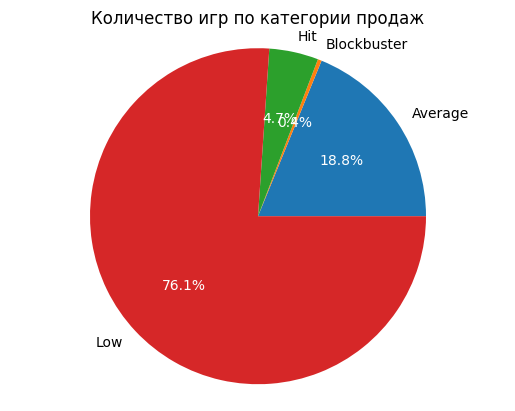

In [79]:
#Категоризация по объему продаж
conditions = [
    (df['Total_Sales'] < 0.5),
    (df['Total_Sales'] >= 0.5) & (df['Total_Sales'] < 2),
    (df['Total_Sales'] >= 2) & (df['Total_Sales'] < 10),
    (df['Total_Sales'] >= 10)
]
values = ['Low', 'Average', 'Hit', 'Blockbuster']
df['Sales_Category'] = np.select(conditions, values, default='Unknown')

agg = df.groupby(by=['Sales_Category'])['Name'].count()
display(agg)
print()

fig, ax = plt.subplots()
patches, texts, autotexts = ax.pie(agg.values, labels=agg.index, autopct='%1.1f%%')

for autotext in autotexts:
    autotext.set_color('white')

for text in texts:
    text.set_color('black')

ax.axis('equal')
plt.title('Количество игр по категории продаж')
plt.show()

### Задание 13. Игры с высокими оценками, но низкими продажами

In [89]:
#Игры с высокими оценками, но низкими продажами
df_hs_ls = df.query("(Critic_Score > 90) & (Total_Sales < 1)")
display(df_hs_ls.pivot_table(
    values=['Name'],
    columns=['Genre'],
    index=['Platform'],
    aggfunc={'Name': 'count'},
    fill_value=0  
))

display(df_hs_ls.query("((Platform == 'PC') & (Genre in ['Role-Playing','Shooter'])) | ((Platform == 'GC') & (Genre == 'Sports'))").sort_values(by='Critic_Score', ascending=False))

Name                                                               \
Genre    Action Adventure Fighting Misc Platform Racing Role-Playing Shooter   
Platform                                                                       
DC            0         0        1    0        0      0            1       0   
GBA           0         0        0    0        2      0            1       0   
GC            2         1        0    0        0      0            0       0   
PC            6         1        1    0        0      0            9       8   
PS            0         0        0    0        0      1            1       0   
PS2           2         0        1    0        1      0            0       0   
PS3           0         2        0    1        1      0            0       0   
PSV           0         0        0    0        0      0            1       0   
Wii           0         0        0    1        1      0            1       1   
WiiU          1         0        0    0        1      0            0       0   
X360          0         0        0    1        0      0            1       0   
XB            2         0        1    0        0      0            0       0   
XOne          1         0        0    0        1      0            0       0   

                                     
Genre    Simulation Sports Strategy  
Platform                             
DC                0      0        0  
GBA               0      0        1  
GC                0      7        0  
PC                3      1        6  
PS                1      1        0  
PS2               0      1        0  
PS3               0      1        0  
PSV               0      0        0  
Wii               0      0        0  
WiiU              0      0        0  
X360              0      0        0  
XB                0      4        0  
XOne              0      0        0

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating,Total_Sales,Sales_Category
9142,The Orange Box,PC,2007.0,Shooter,0.00,0.11,0.0,0.03,96.0,9.3,M,0.14,Low
4710,BioShock,PC,2007.0,Shooter,0.01,0.39,0.0,0.02,96.0,8.5,M,0.42,Low
2703,Portal 2,PC,2011.0,Shooter,0.33,0.32,0.0,0.10,95.0,8.8,E10+,0.75,Average
3067,BioShock Infinite,PC,2013.0,Shooter,0.29,0.30,0.0,0.07,94.0,8.5,M,0.66,Average
3889,Madden NFL 2004,GC,2003.0,Sports,0.40,0.10,0.0,0.01,94.0,7.7,E,0.51,Average
6583,The Elder Scrolls IV: Oblivion,PC,2006.0,Role-Playing,0.01,0.20,0.0,0.04,94.0,8.1,M,0.25,Low
4880,Mass Effect 2,PC,2010.0,Role-Playing,0.01,0.32,0.0,0.06,94.0,8.8,M,0.39,Low
2851,The Witcher 3: Wild Hunt,PC,2015.0,Role-Playing,0.21,0.46,0.0,0.05,93.0,9.3,M,0.72,Average
15866,Unreal Tournament 2004,PC,2004.0,Shooter,0.00,0.01,0.0,0.00,93.0,8.9,M,0.01,Low
9159,Star Wars: Knights of the Old Republic,PC,2003.0,Role-Playing,0.01,0.10,0.0,0.02,93.0,9.0,T,0.13,Low


### Задание 14. Тепловая карта корреляций

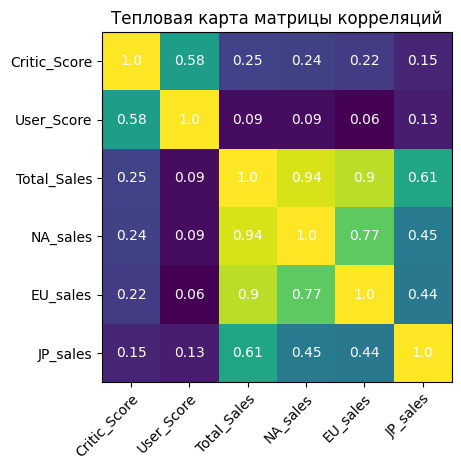

In [26]:
#Тепловая карта кореляций
corr = df[['Critic_Score', 'User_Score', 'Total_Sales', 'NA_sales', 'EU_sales', 'JP_sales']].corr(method='pearson')

fig, ax = plt.subplots()
im = ax.imshow(corr)

ax.set_xticks(range(len(list(corr.columns))), labels=list(corr.columns),
              rotation=45, ha="right", rotation_mode="anchor")
ax.set_yticks(range(len(list(corr.index))), labels=list(corr.index))

# Loop over data dimensions and create text annotations.
for i in range(len(list(corr.index))):
    for j in range(len(list(corr.columns))):
        text = ax.text(j, i, round(corr.iloc[i, j],2),
                       ha="center", va="center", color="w")

ax.set_title("Тепловая карта матрицы корреляций")
fig.tight_layout()
plt.show()

### Задание 15. Сравнение десятилетий

In [39]:
#Сравнение десятилетий
conditions = [
    (df['Year_of_Release'] < 1990),
    (df['Year_of_Release'] >= 1990) & (df['Year_of_Release'] < 2000),
    (df['Year_of_Release'] >= 2000) & (df['Year_of_Release'] < 2010),
    (df['Year_of_Release'] >= 2010)
]
values = ['First', 'Second', 'Third', 'Fourth']
df['Decade_YOR'] = np.select(conditions, values, default='Unknown')

df_popular = df.pivot_table(
    values=['Total_Sales'],
    columns=['Decade_YOR'],
    index=['Genre'],
    aggfunc={'Total_Sales': 'sum'},
    fill_value=0
)
df_popular.columns = values
#print(df_popular)

for decade in values:
    value = list(df_popular.sort_values(by=decade, ascending=False)[decade].index)
    print(f'{decade} decade. Most popular genre is {value[0]}')

First decade. Most popular genre is Platform
Second decade. Most popular genre is Action
Third decade. Most popular genre is Platform
Fourth decade. Most popular genre is Action
